In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import json

In [2]:
# 获取当前文件夹下的所有文件夹
folders = [f for f in os.listdir('.') if os.path.isdir(f)]
# 筛选出文件夹名 split('_') 后长度为 3 的文件夹
filtered_folders = [folder for folder in folders if len(folder.split('_')) == 3]
print(filtered_folders)

model_name = set()
for i in filtered_folders:
  # 获取文件夹名 split('_') 后的第一个和第三个元素
  parts = i.split('_')
  model_name.add(parts[0])
  model_name.add(parts[2])
  
print(model_name)

['direct_vs_KP', 'direct_vs_KPBloom', 'direct_vs_vanillaRAG', 'KP_vs_KPBloom', 'vanillaRAG_vs_KP', 'vanillaRAG_vs_KPBloom']
{'KP', 'direct', 'vanillaRAG', 'KPBloom'}


In [3]:
for folder in filtered_folders:
  for root, dirs, files in os.walk(folder):
    for file in files:
      if '_evaluation.csv' in file:
        old_path = os.path.join(root, file)
        new_path = os.path.join(root, 'evaluation.csv')
        os.rename(old_path, new_path)
        print(f"Renamed: {old_path} -> {new_path}")

In [4]:
def read_csv_from_folder(model_a, model_b, filename):
  
  df = pd.read_csv(filename)
  # Replace 'Answer 1' and 'Answer 2' in the dataframe with model_a and model_b names
  df.replace({'Answer 1': model_a, 'Answer 2': model_b}, inplace=True)
  df['Model A'] = model_a
  df['Model B'] = model_b  
  return df

In [25]:
read_csv_from_folder('direct', 'KP', r'direct_vs_KP/evaluation.csv')
# df_list.append(read_csv_from_folder('direct', 'KPBloom', r'direct_vs_KPBloom/evaluation.csv'))
# df_list.append(read_csv_from_folder('direct', 'vanillaRAG', r'direct_vs_vanillaRAG/evaluation.csv'))
# df_list.append(read_csv_from_folder('KP', 'KPBloom', r'KP_vs_KPBloom/evaluation.csv'))
# df_list.append(read_csv_from_folder('vanillaRAG', 'KP', r'vanillaRAG_vs_KP/evaluation.csv'))
# df_list.append(read_csv_from_folder('vanillaRAG', 'KPBloom', r'vanillaRAG_vs_KPBloom/evaluation.csv'))

,Completeness,Knowledge Alignment,Diversity,Overall,Model A,Model B
0,direct,direct,direct,direct,direct,KP
1,KP,KP,KP,KP,direct,KP
2,KP,KP,direct,KP,direct,KP
3,KP,direct,direct,direct,direct,KP
4,KP,KP,direct,KP,direct,KP
5,KP,KP,direct,KP,direct,KP
6,KP,KP,direct,KP,direct,KP
7,KP,KP,KP,KP,direct,KP
8,direct,KP,direct,direct,direct,KP
9,KP,KP,direct,KP,direct,KP


In [7]:
model_name_list = list(model_name)
print(model_name_list)
model_name_list = ['KPBloom', 'KP', 'vanillaRAG', 'direct']

['KP', 'direct', 'vanillaRAG', 'KPBloom']


In [ ]:
model_name_list = list(model_name)
# heatmap_data = np.zeros((len(model_name_list), len(model_name_list)))
winning_dict = {}
for i in range(len(model_name_list)):
  for j in range(len(model_name_list)):
    current_model_a = model_name_list[i]
    current_model_b = model_name_list[j]
    if i == j:
      winning_dict[(current_model_a, current_model_b)] = 0.5
      winning_dict[(current_model_b, current_model_a)] = 0.5
    else:
      if f"{current_model_a}_vs_{current_model_b}" in filtered_folders:
        df = read_csv_from_folder(current_model_a, current_model_b, f"{current_model_a}_vs_{current_model_b}/evaluation.csv")
        overall_series = df["Overall"]
        total = len(overall_series)
        a_wins = (overall_series == current_model_a).sum()/total
        b_wins = (overall_series == current_model_b).sum()/total
        print(f"{current_model_a} vs {current_model_b}: {a_wins} {b_wins}")
        winning_dict[(current_model_a, current_model_b)] = a_wins
        winning_dict[(current_model_b, current_model_a)] = b_wins
        
      elif f"{current_model_b}_vs_{current_model_a}" in filtered_folders:
        pass

KP vs KPBloom: 0.7857142857142857 0.21428571428571427
direct vs KP: 0.21428571428571427 0.7857142857142857
direct vs vanillaRAG: 0.42857142857142855 0.5714285714285714
direct vs KPBloom: 0.35714285714285715 0.6428571428571429
vanillaRAG vs KP: 0.2857142857142857 0.7142857142857143
vanillaRAG vs KPBloom: 0.2857142857142857 0.7142857142857143


In [18]:
winning_dict

{('KP', 'KP'): 0.5,
 ('KP', 'KPBloom'): np.float64(0.7857142857142857),
 ('KPBloom', 'KP'): np.float64(0.21428571428571427),
 ('direct', 'KP'): np.float64(0.21428571428571427),
 ('KP', 'direct'): np.float64(0.7857142857142857),
 ('direct', 'direct'): 0.5,
 ('direct', 'vanillaRAG'): np.float64(0.42857142857142855),
 ('vanillaRAG', 'direct'): np.float64(0.5714285714285714),
 ('direct', 'KPBloom'): np.float64(0.35714285714285715),
 ('KPBloom', 'direct'): np.float64(0.6428571428571429),
 ('vanillaRAG', 'KP'): np.float64(0.2857142857142857),
 ('KP', 'vanillaRAG'): np.float64(0.7142857142857143),
 ('vanillaRAG', 'vanillaRAG'): 0.5,
 ('vanillaRAG', 'KPBloom'): np.float64(0.2857142857142857),
 ('KPBloom', 'vanillaRAG'): np.float64(0.7142857142857143),
 ('KPBloom', 'KPBloom'): 0.5}

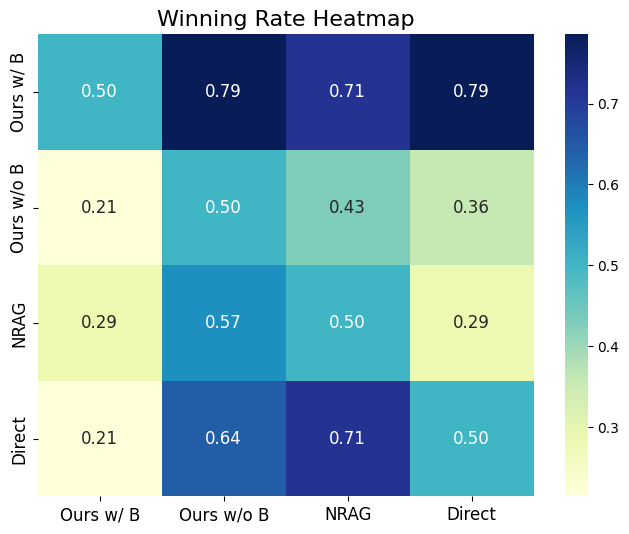

In [31]:
# 创建一个空的 DataFrame，用于存储热力图数据
heatmap_df = pd.DataFrame(index=model_name_list, columns=model_name_list)

# 填充 DataFrame 的值
for (model_a, model_b), value in winning_dict.items():
  heatmap_df.loc[model_a, model_b] = value

# 将数据类型转换为浮点数
heatmap_df = heatmap_df.astype(float)

# 绘制热力图
plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_df, 
    annot=True, 
    fmt=".2f", 
    cmap="YlGnBu", 
    xticklabels=['Ours w/ B', 'Ours w/o B', 'NRAG', 'Direct'], 
    yticklabels=['Ours w/ B', 'Ours w/o B', 'NRAG', 'Direct'], 
    annot_kws={"size": 12}  # 设置注释字体大小
)
plt.title("Winning Rate Heatmap", fontsize=16)  # 设置标题字体大小
plt.xticks(fontsize=12)  # 设置x轴标签字体大小
plt.yticks(fontsize=12)  # 设置y轴标签字体大小
plt.savefig(rf'D:\Dennis\OneDrive\yr4sem2\fyp\final_report\winning_rate_heatmap.pdf', bbox_inches='tight', dpi=300)  # 保存热力图为PDF文件，设置边距和分辨率
plt.show()

In [36]:
model_name_list = list(model_name)
# heatmap_data = np.zeros((len(model_name_list), len(model_name_list)))
specifically_winning_list = []
for i in range(len(model_name_list)):
  for j in range(len(model_name_list)):
    for col in ['Completeness','Knowledge Alignment','Diversity','Overall']:
      current_model_a = model_name_list[i]
      current_model_b = model_name_list[j]
      
      # specifically_winning_dict[(current_model_b, current_model_a)] = {}
      if i == j:
        specifically_winning_list.append((current_model_a, current_model_b, col, 0.5))
      else:
        if f"{current_model_a}_vs_{current_model_b}" in filtered_folders:
          df = read_csv_from_folder(current_model_a, current_model_b, f"{current_model_a}_vs_{current_model_b}/evaluation.csv")
          overall_series = df[col]
          total = len(overall_series)
          a_wins = (overall_series == current_model_a).sum()/total
          b_wins = (overall_series == current_model_b).sum()/total
          print(f"{current_model_a} vs {current_model_b} {col}: {a_wins} {b_wins}")
          specifically_winning_list.append((current_model_a, current_model_b, col, a_wins))
          specifically_winning_list.append((current_model_b, current_model_a, col, b_wins))
          
        elif f"{current_model_b}_vs_{current_model_a}" in filtered_folders:
          pass

KP vs KPBloom Completeness: 0.7857142857142857 0.21428571428571427
KP vs KPBloom Knowledge Alignment: 0.6428571428571429 0.35714285714285715
KP vs KPBloom Diversity: 0.5714285714285714 0.42857142857142855
KP vs KPBloom Overall: 0.7857142857142857 0.21428571428571427
direct vs KP Completeness: 0.14285714285714285 0.8571428571428571
direct vs KP Knowledge Alignment: 0.14285714285714285 0.8571428571428571
direct vs KP Diversity: 0.7142857142857143 0.2857142857142857
direct vs KP Overall: 0.21428571428571427 0.7857142857142857
direct vs vanillaRAG Completeness: 0.42857142857142855 0.5714285714285714
direct vs vanillaRAG Knowledge Alignment: 0.35714285714285715 0.6428571428571429
direct vs vanillaRAG Diversity: 0.6428571428571429 0.35714285714285715
direct vs vanillaRAG Overall: 0.42857142857142855 0.5714285714285714
direct vs KPBloom Completeness: 0.2857142857142857 0.7142857142857143
direct vs KPBloom Knowledge Alignment: 0.2857142857142857 0.7142857142857143
direct vs KPBloom Diversity: 

In [51]:
specifically_winning_list.sort()
whole_df = pd.DataFrame(specifically_winning_list, columns=['Model A', 'Model B', 'Metric', 'Winning Rate'])
result = whole_df[whole_df['Model A'] == 'KPBloom']
result_pivot = result.pivot(index='Model B', columns='Metric', values='Winning Rate')
print(result_pivot.round(4))

Metric      Completeness  Diversity  Knowledge Alignment  Overall
Model B                                                          
KP                0.2143     0.4286               0.3571   0.2143
KPBloom           0.5000     0.5000               0.5000   0.5000
direct            0.7143     0.3571               0.7143   0.6429
vanillaRAG        0.7857     0.4286               0.7143   0.7143
